---
toc-title: 
format: 
  markdown:
    code-fold: true
---

Let's load the original score---well, a solo clarinet version, which includes just the bee's flight!---and look at the first three bars.

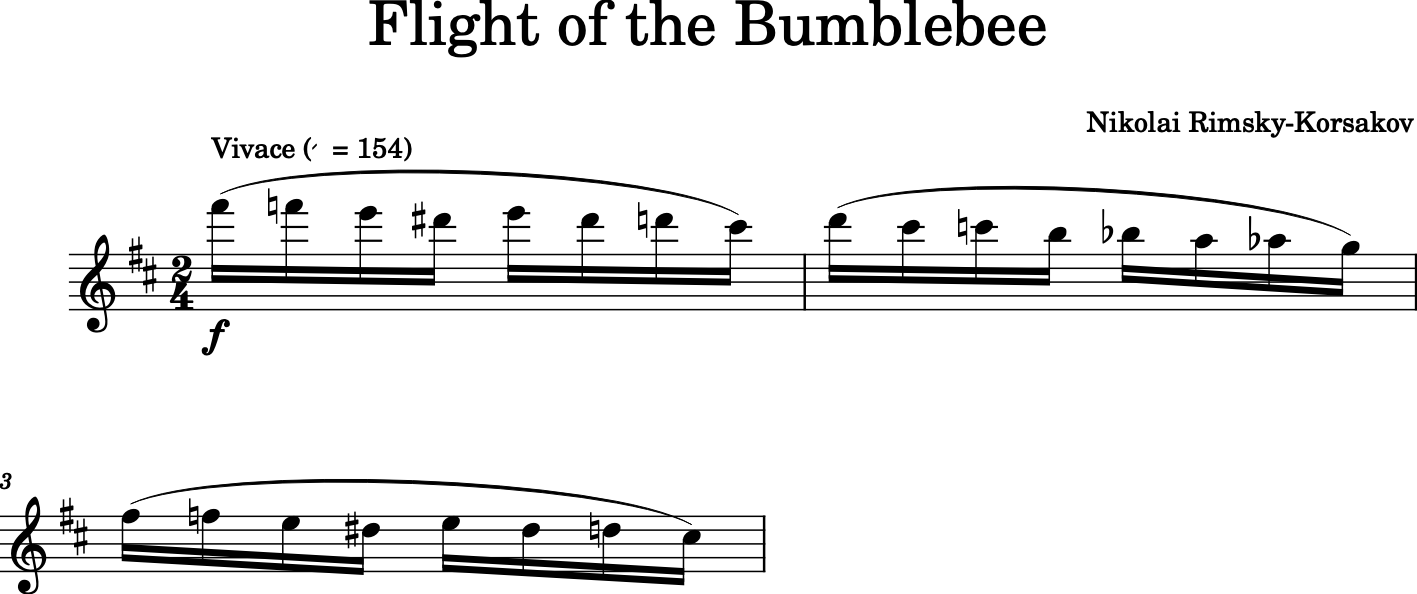

In [26]:
from music21 import *
import copy

score = converter.parse('./assets/flight-of-the-bumblebee-for-b-clarinet.mxl')
score.metadata.composer = "Nikolai Rimsky-Korsakov"
score.metadata.movementName = "Flight of the Bumblebee"

score.measures(1,3).show()

From looking at the pianoroll, we can see that the bee is going ALLL over the place. 
Not very streamlined. Lots of extra energy being spent.

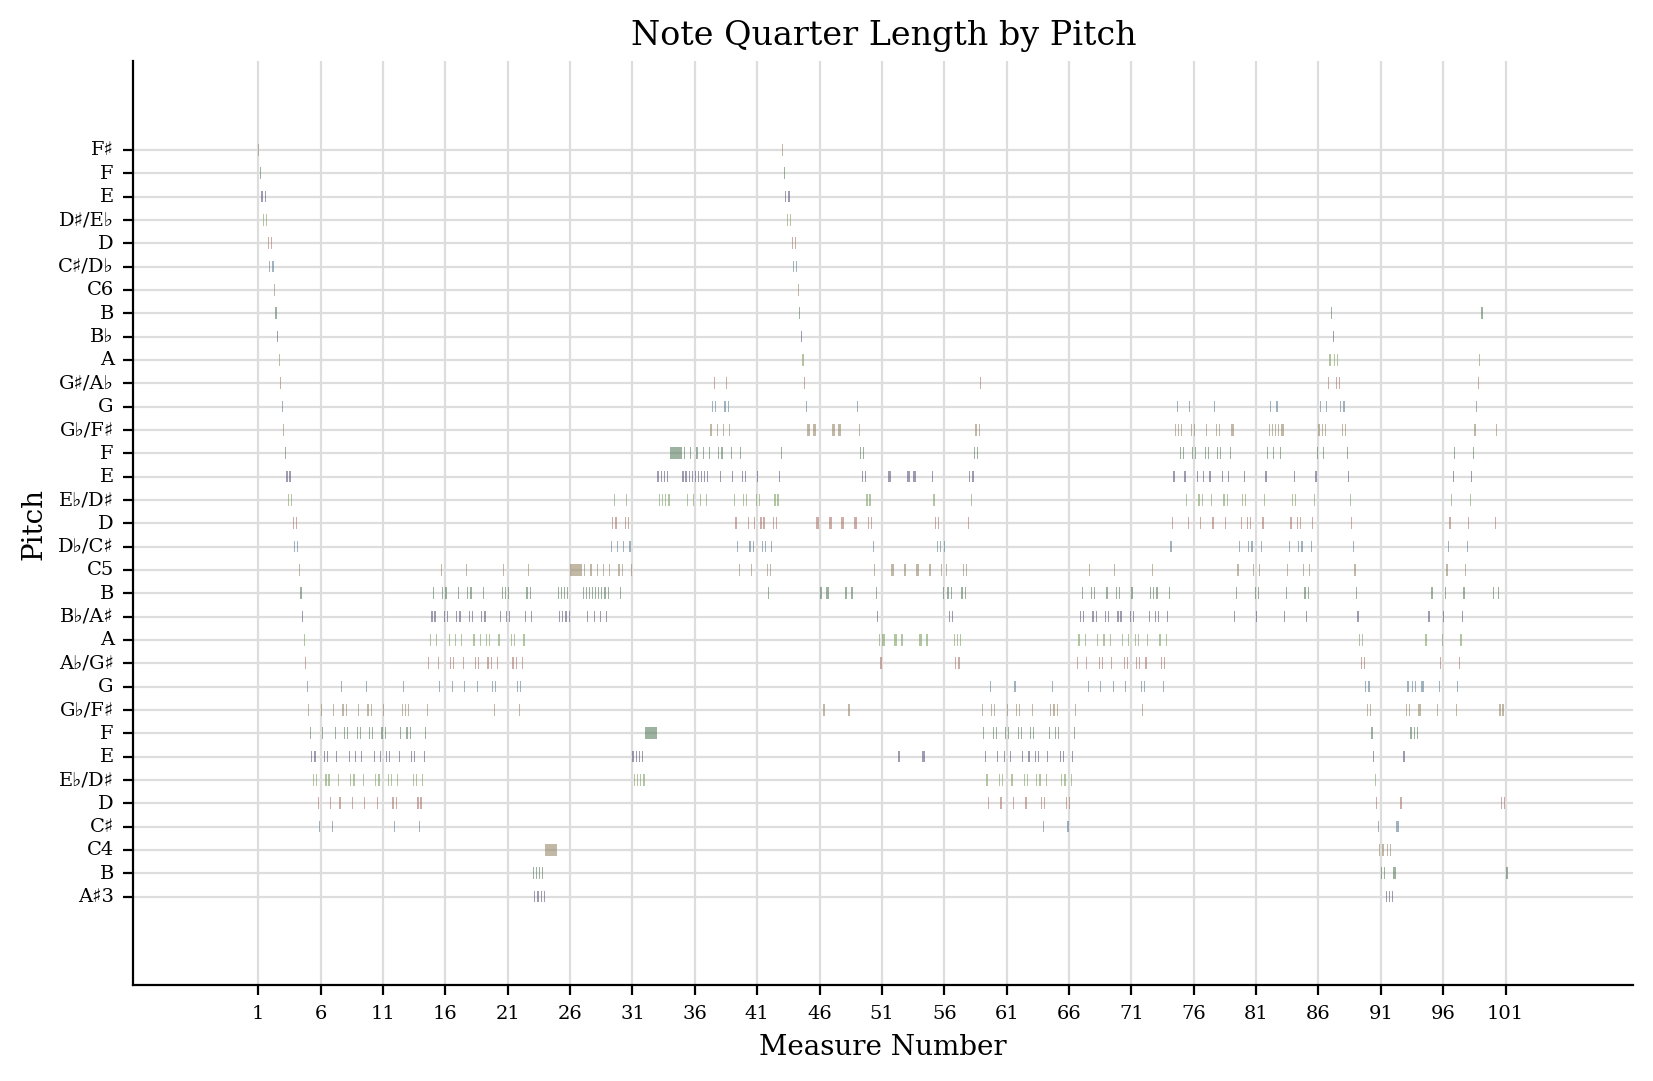

In [4]:
score.plot('pianoroll')

In [5]:
score.measures(1,10).show('midi')

Looks like we use every single note between the lowest note (A#3) and the highest (F#6)
at least once. Ironically, we hit the "B" an awful lot!!!! Doesn't really mean anything 
though, becasue this is a clarinet score, which means it is transposed

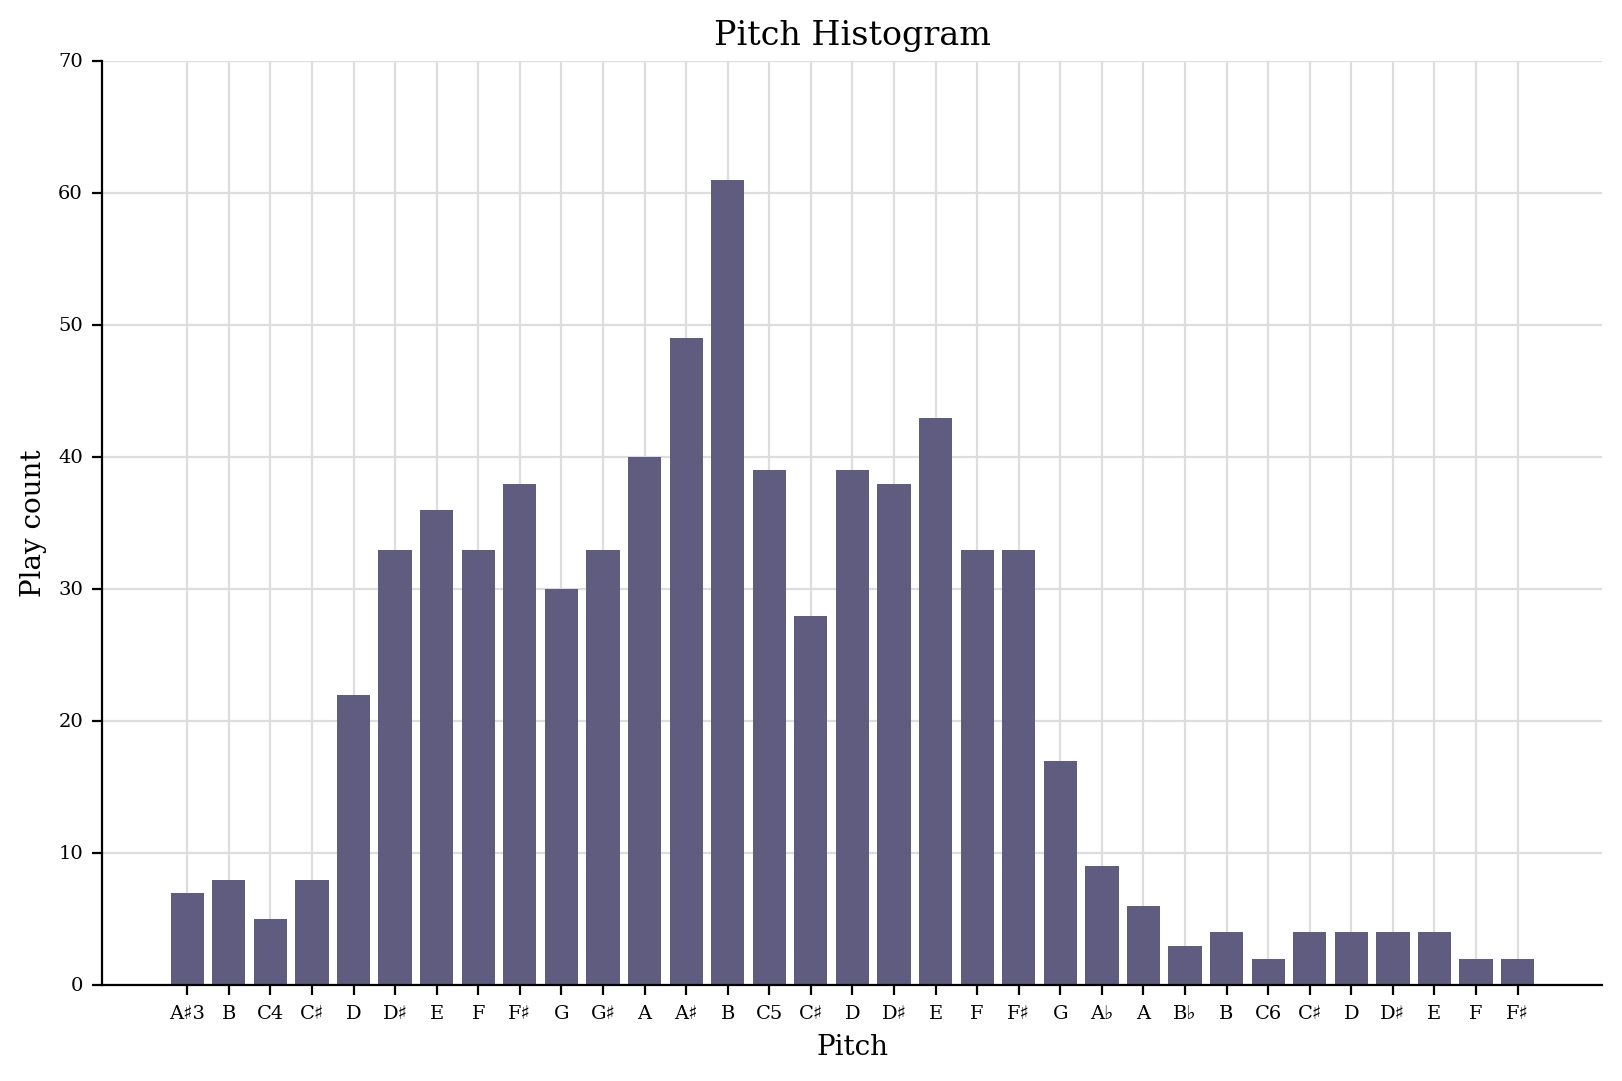

In [16]:
score.plot('histogram', 'pitch', xHideUnused=False,
          xLabel="Pitch", yLabel="Play count")

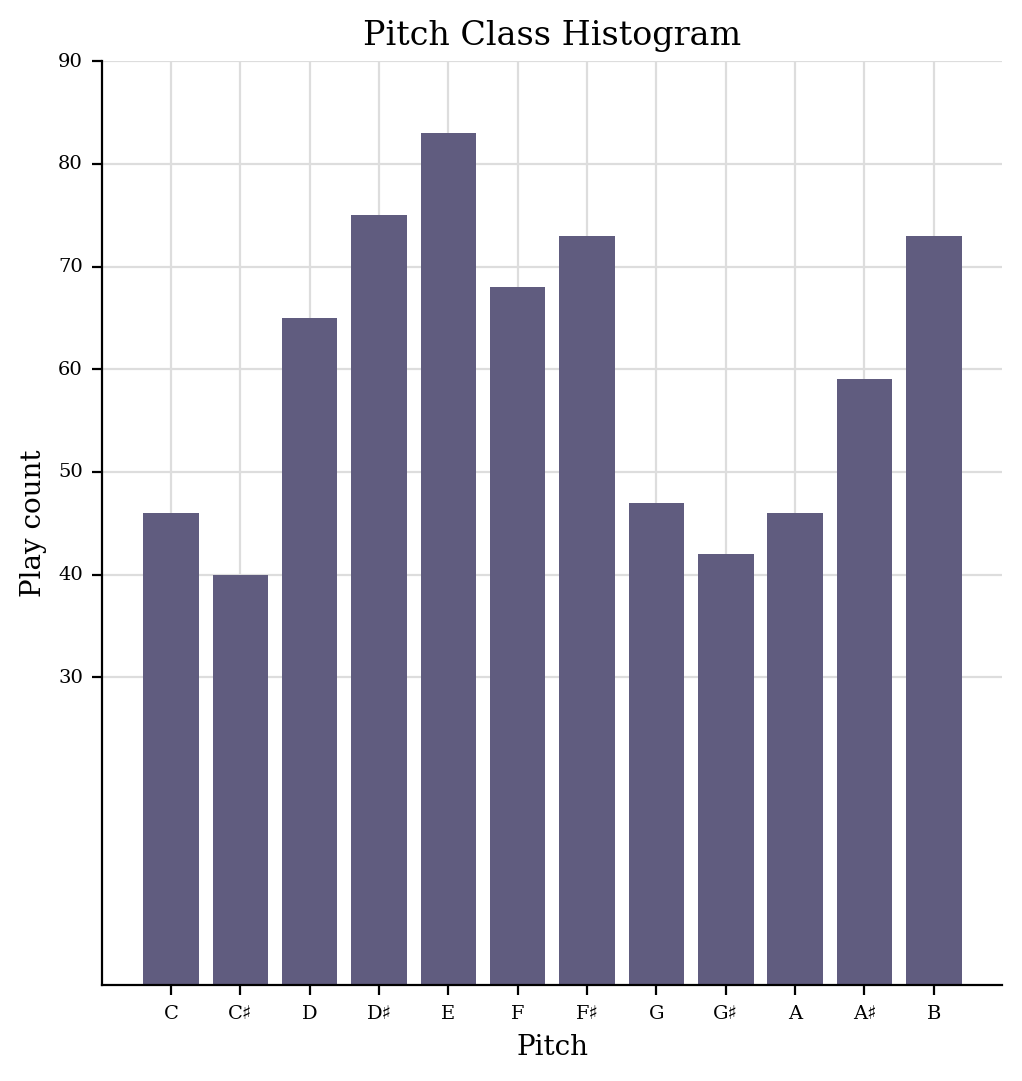

In [7]:
score.plot('histogram', 'pitchClass', xHideUnused=False,
          xLabel="Pitch", yLabel="Play count")

What's our note count? From a [previous notebook](../TODO) we have a function for that!

In [17]:
def count_notes_played(input):
    total = 0
    for n in input.recurse().notes:
        if n.tie and n.tie.type != "start":
            continue
        if len(n.expressions) and type(n.expressions[0]) is expressions.Tremolo:
            if n.expressions[0]._numberOfMarks != 1:
                print("Unhandled: tremolo notation with >1 slash")
            total += 2
        else:
            total += 1
    return total
        
print("Notes played: " + str(count_notes_played(score)))

Notes played: 717


What happens if we turn this into flight of the bumble B?
Let's persist the octave of the original, though.

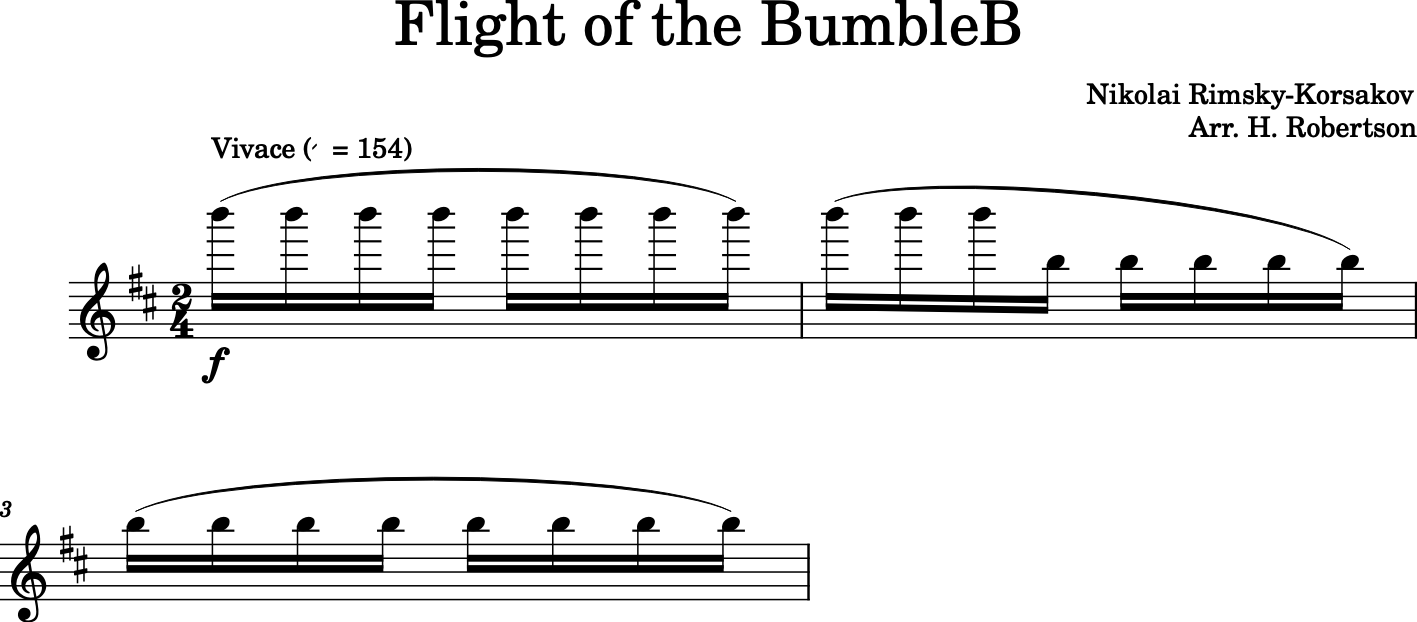

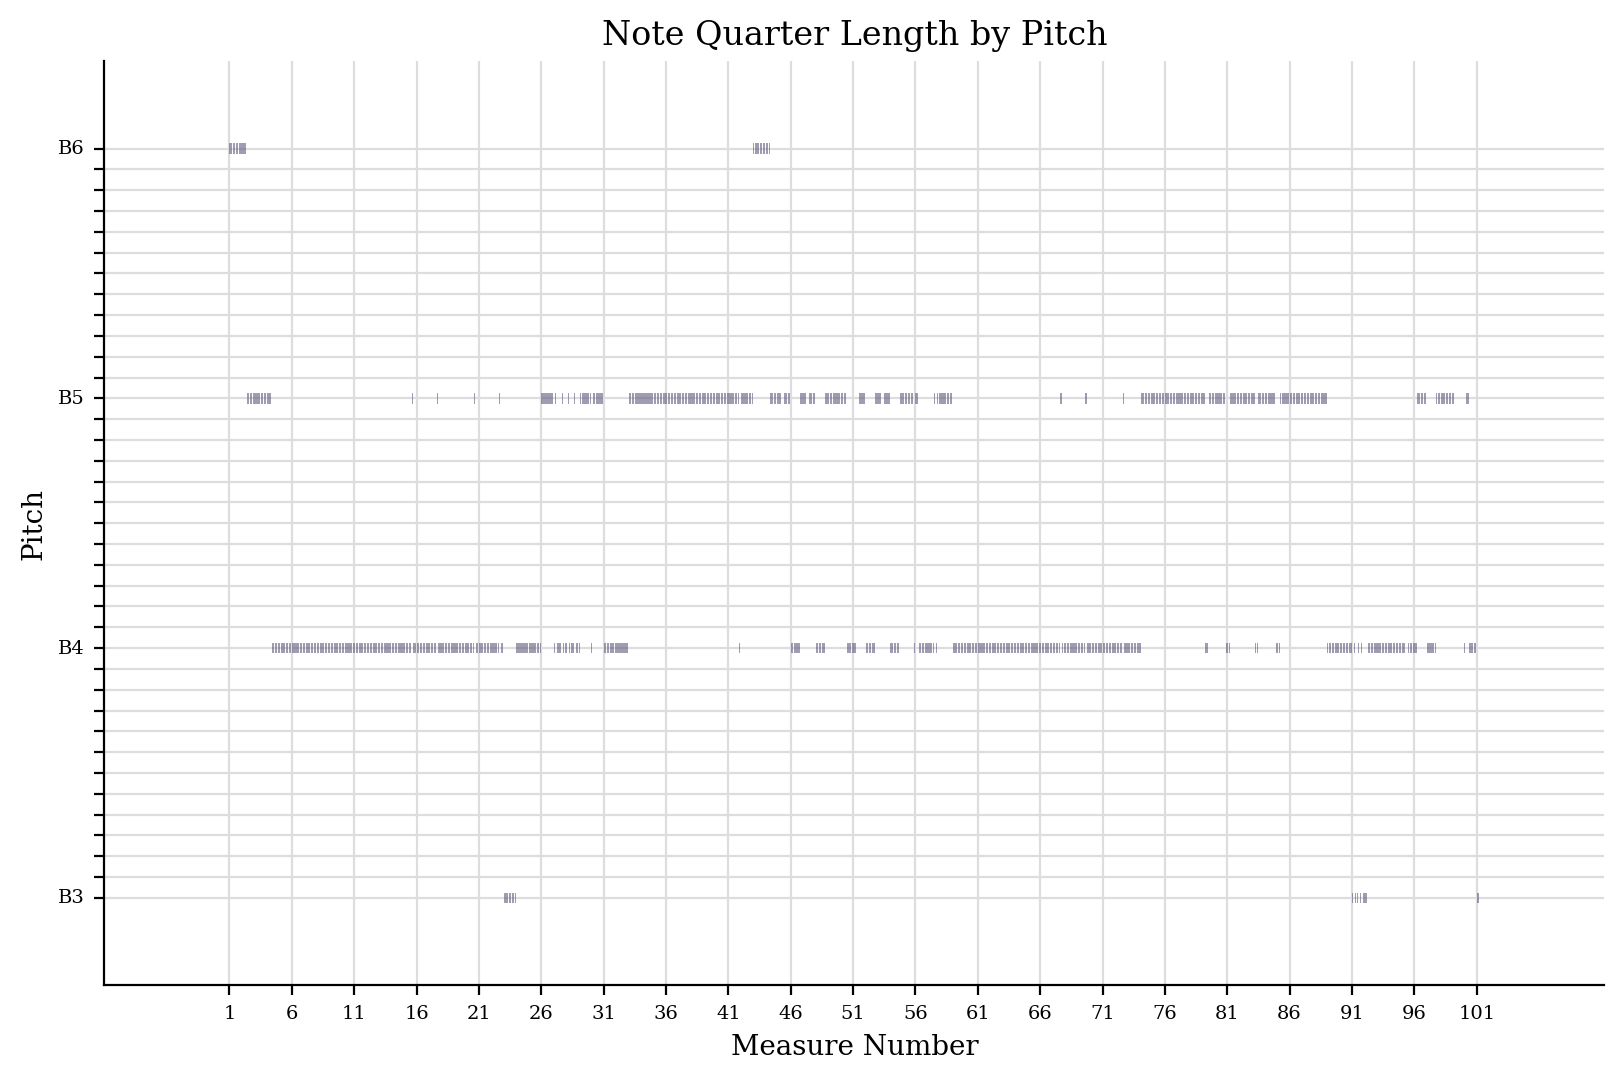

In [18]:
score_b = copy.deepcopy(score)
score_b.metadata.composer = "Nikolai Rimsky-Korsakov\nArr. H. Robertson"
score_b.metadata.movementName = "Flight of the BumbleB"

for n in score_b.recurse().notes:
    n.pitch.name = ('B')

score_b.measures(1,3).show()
score_b.show('midi')
score_b.plot('pianoroll')

That first bee did not take a very direct route. 
Let's update its itinerary, assuming that the bumblebee has traveled exactly 
where it wanted to travel (i.e., preserve all pitches) and spent as long as it 
intended at each place based on how tired it was along its journey (preserve duration)
while re-ordering its destinations (i.e., do not preserve order).

Aka...flight of the traveling salesbee?

In [10]:
score_traveling = copy.deepcopy(score)
score_traveling.metadata.composer = "Nikolai Rimsky-Korsakov\nArr. H. Robertson"
score_traveling.metadata.movementName = "Flight of the Traveling Salesbee"

sorted_notes = sorted(score.recurse().notes, key=lambda n:n.pitch.midi, reverse=True)

# Iterate through all but one note...
for i in range(0, len(score_traveling.recurse().notes) - 1):
    # Shift the selected note by one...
    score_traveling.recurse().notes[i].pitch.midi = sorted_notes[i+1].pitch.midi

Because this salesbee is TRAVELING, it needs to [return to the origin city](https://en.wikipedia.org/wiki/Travelling_salesman_problem)!

In [20]:
score_traveling.recurse().notes[-1].pitch.midi = sorted_notes[0].pitch.midi

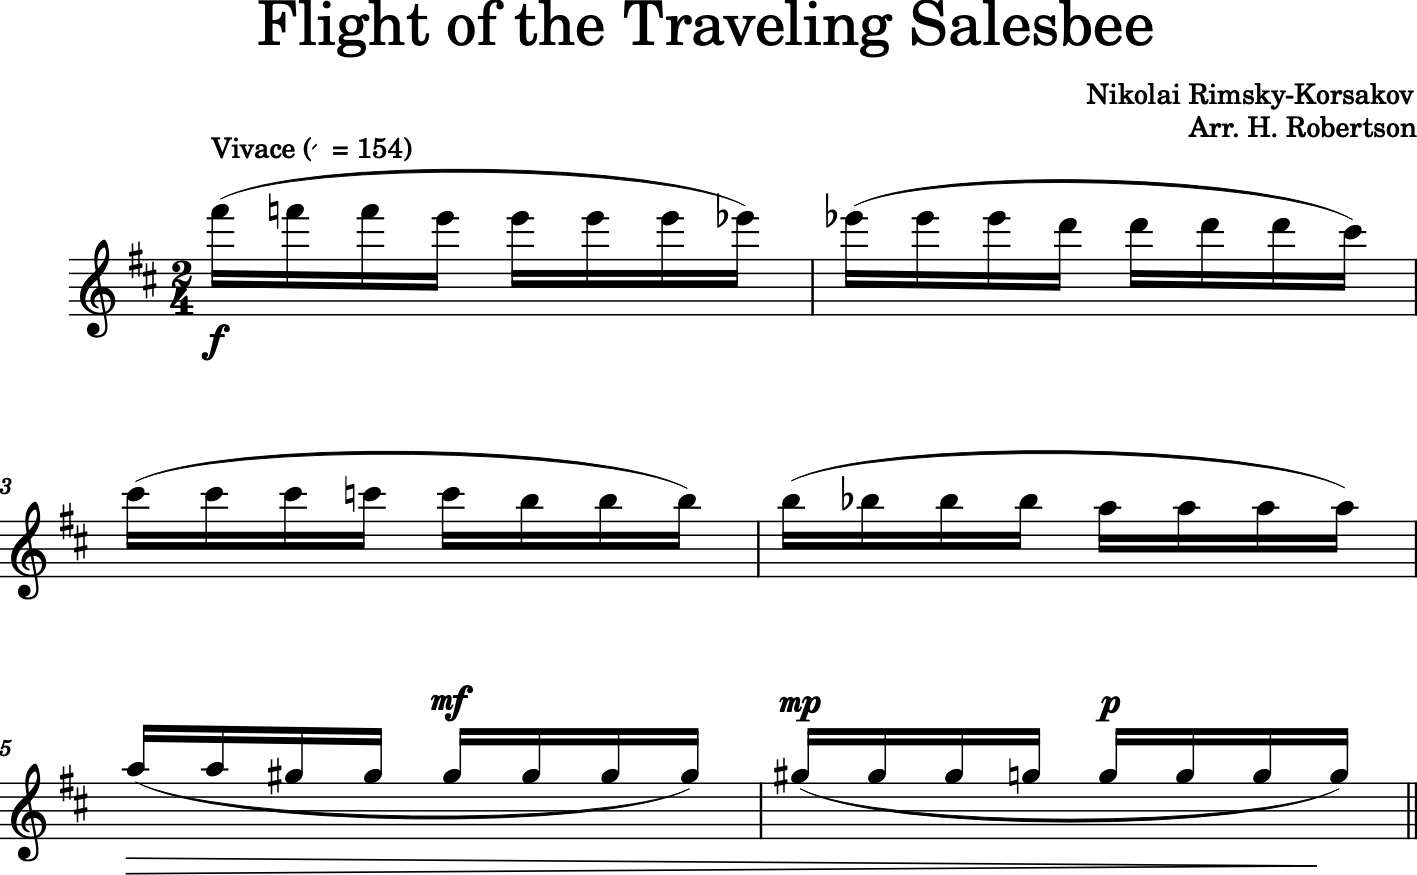

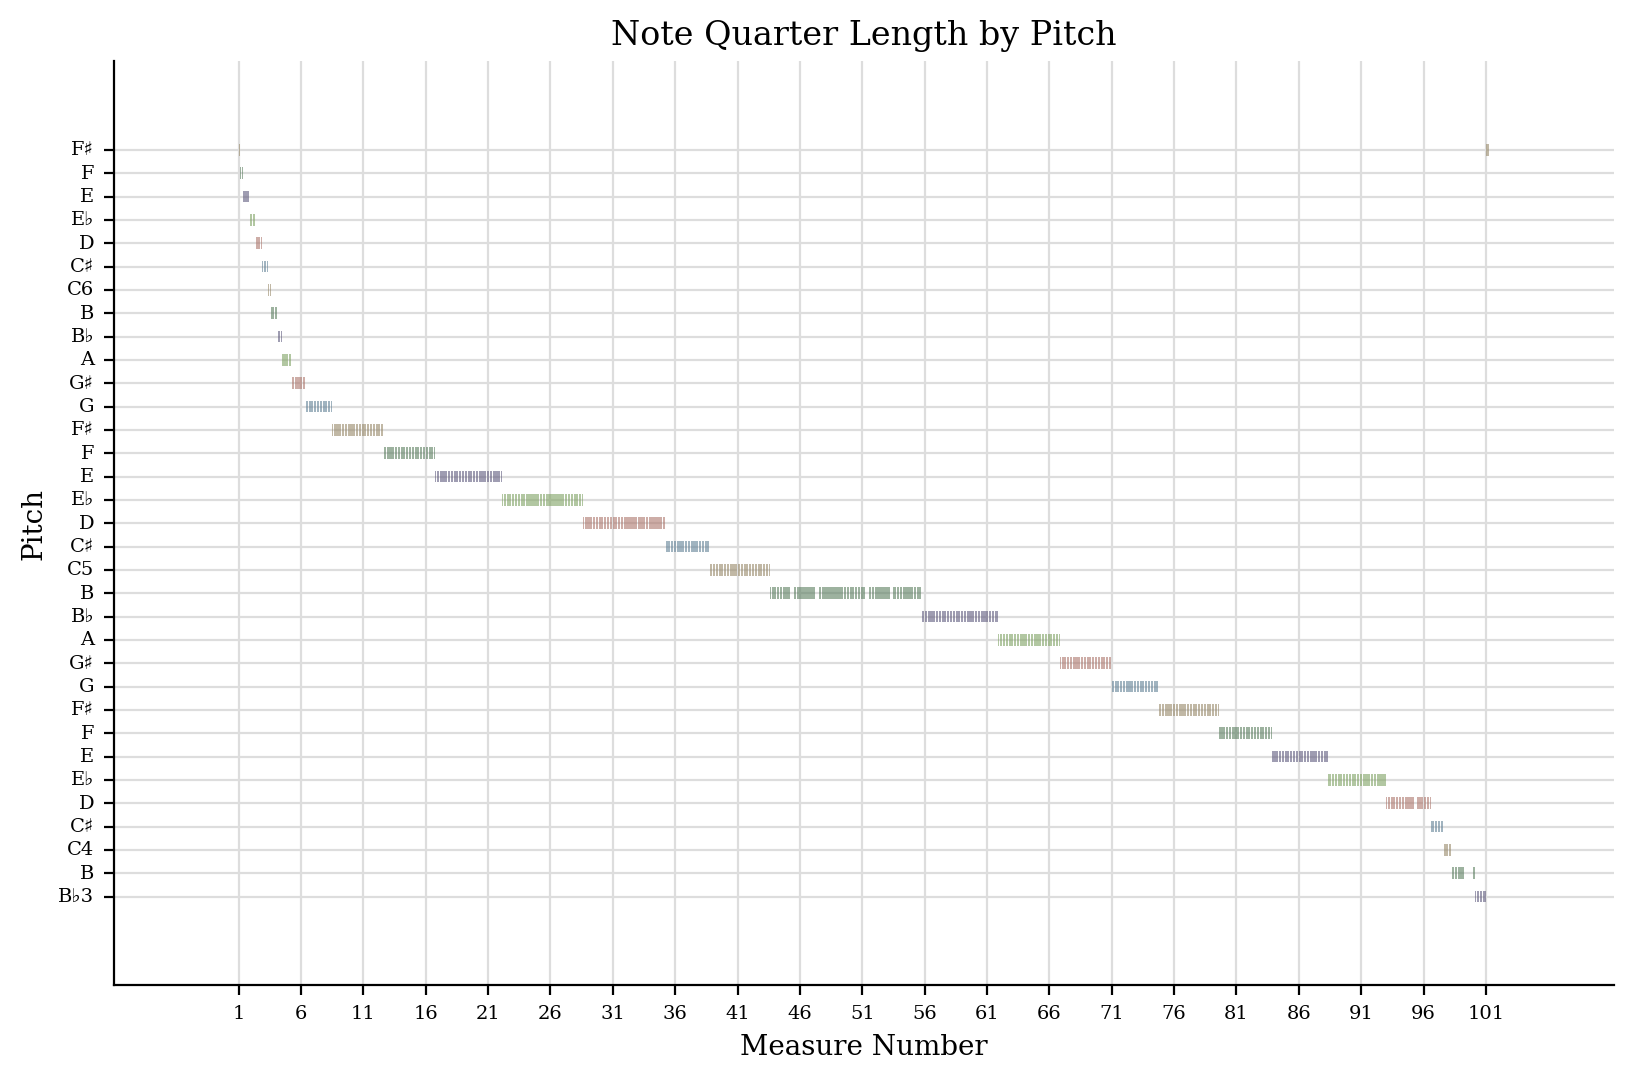

In [21]:
score_traveling.measures(1,6).show()
score_traveling.show('midi')
score_traveling.plot('pianoroll')

The bee's friend Crow has no time for all this bumbling around. 
Crow thinks that Bumblebee's original path had merit, but proposes a less 
circuitous version.

Crow thinks that Bee shouldn't bother traveling in tiny little bursts (any distance
of a single semitone) and should instead hang out at its most recent location until 
a larger movement is required---and then go directly to it. 

It may still visit that site multiple times (after all, bumblebee's wings gotta beat!)
(and also I cannot for the life of me figure out how to convert a note to a rest,
which ought to be trivially easy but does not seem to be!)

In [22]:
score_crow = copy.deepcopy(score)
score_crow.metadata.composer = "Nikolai Rimsky-Korsakov\nArr. H. Robertson"
score_crow.metadata.movementName = "As the Bumblebee Flies"

MAX_SEMITONE_DISTANCE_WORTH_FLYING = 4

prev_pitch = score_crow.recurse().notes[0].pitch
for i in range(1, len(score_crow.recurse().notes) - 1):
    if type(score_crow.recurse().notes[i]) == note.Rest:
        continue
    tentative_pitch = score_crow.recurse().notes[i].pitch
    if abs(tentative_pitch.midi - prev_pitch.midi) <= MAX_SEMITONE_DISTANCE_WORTH_FLYING:
        score_crow.recurse().notes[i].pitch = prev_pitch
       
    else:
        # No change to the current note, and set it as the next one
        prev_pitch = tentative_pitch

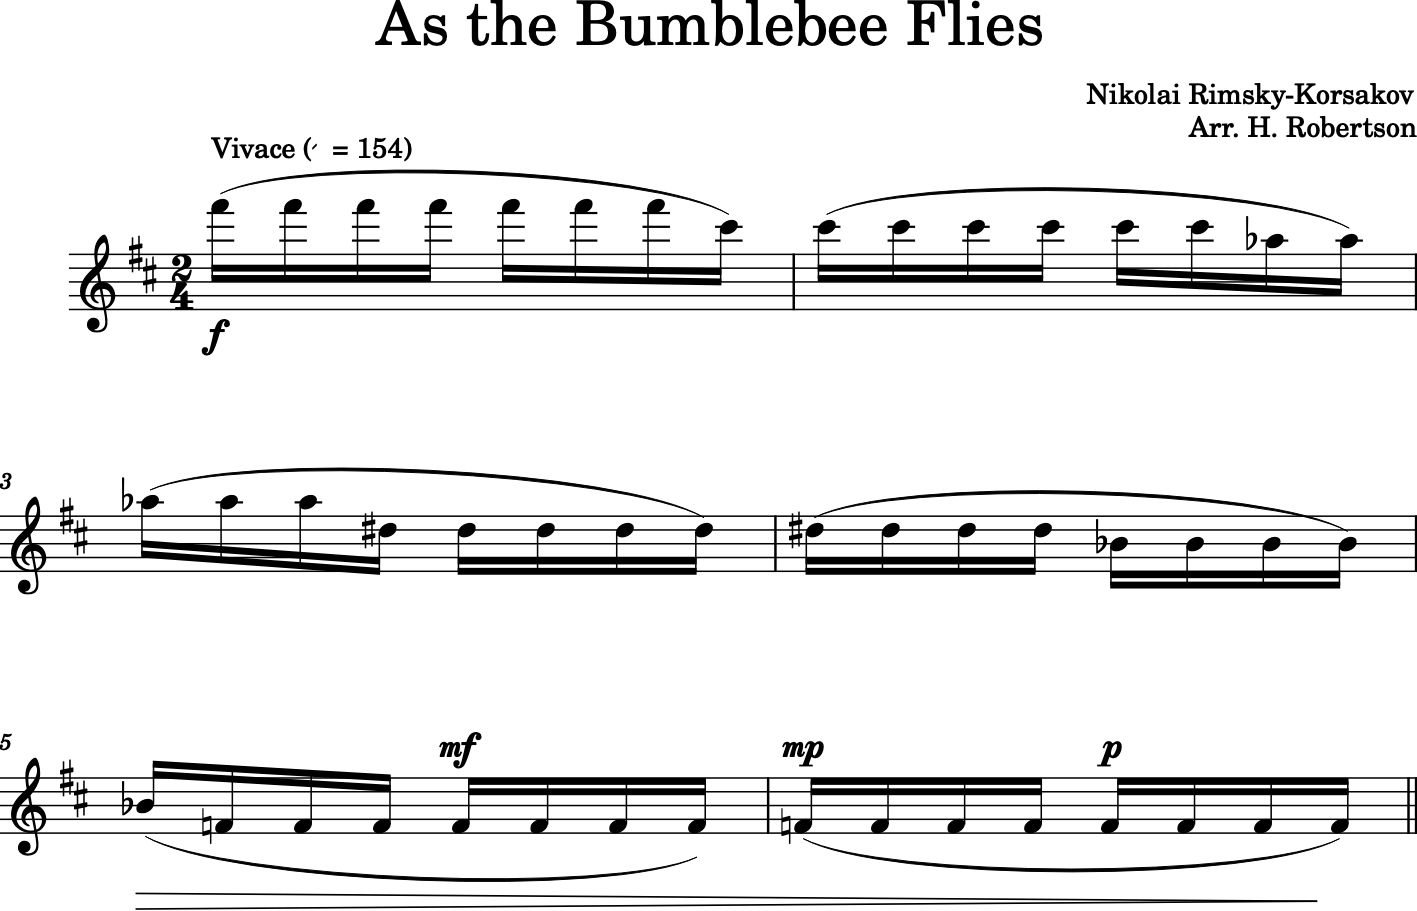

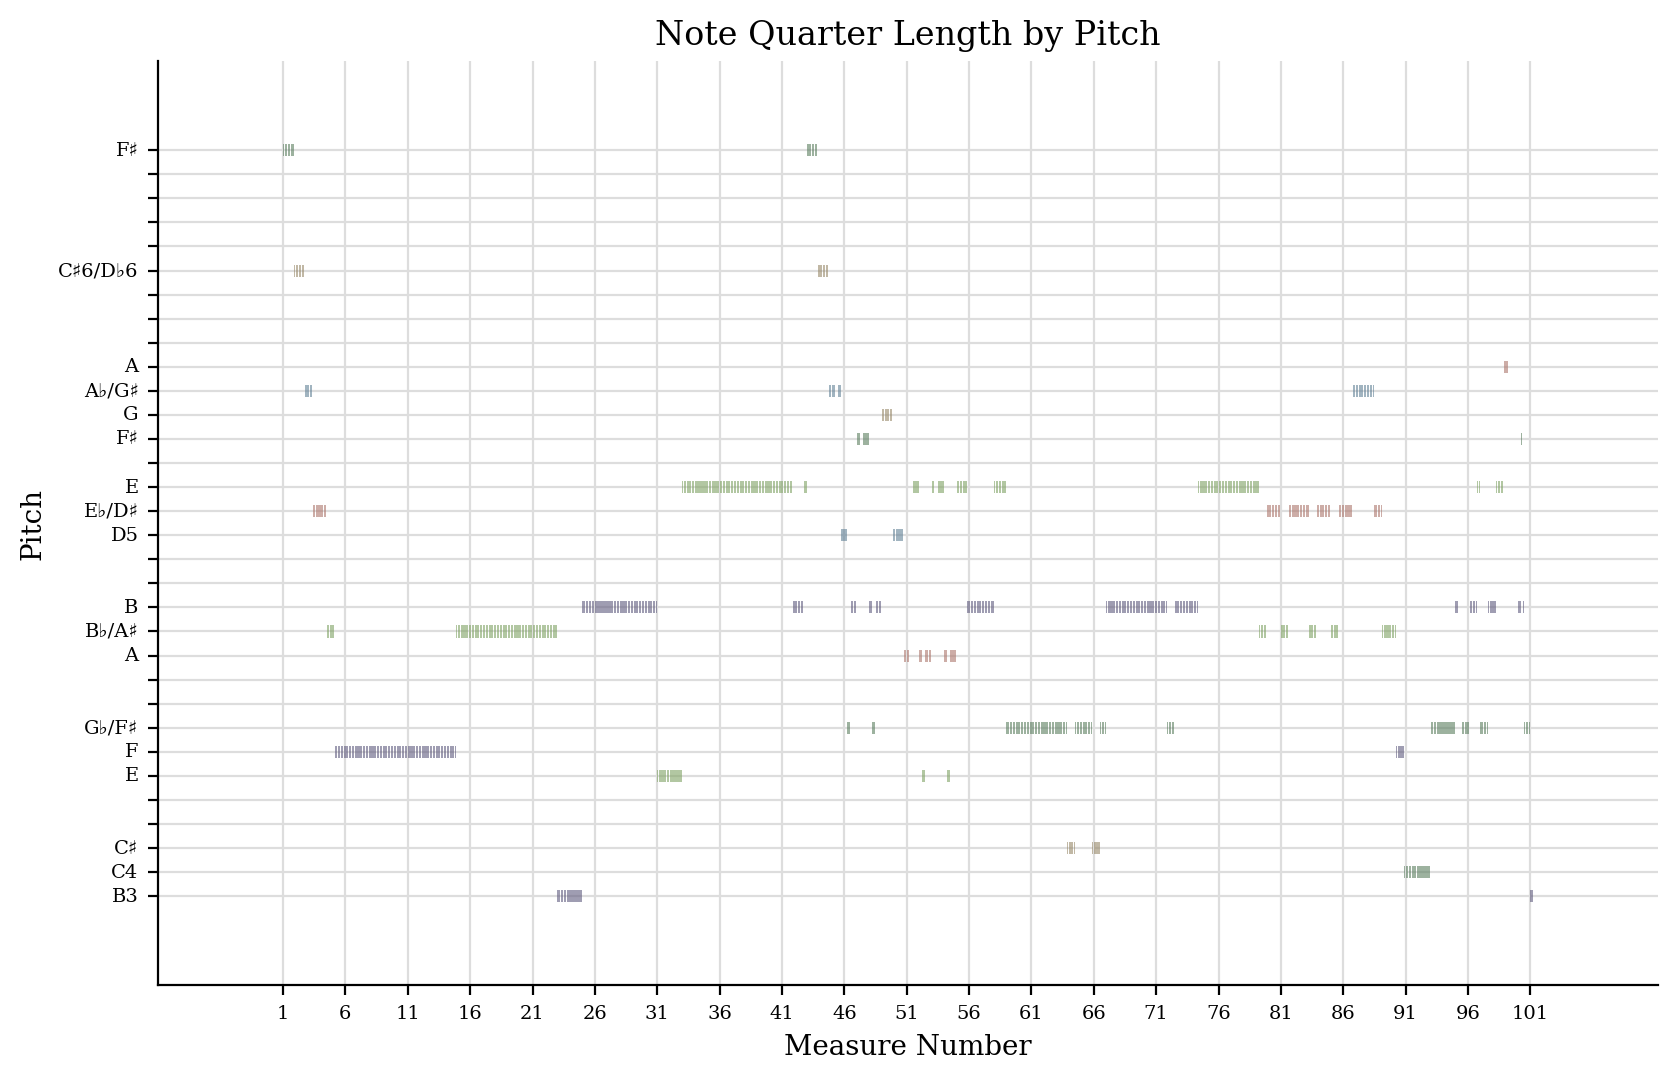

In [23]:
score_crow.measures(1,6).show()
score_crow.show('midi')
score_crow.plot('pianoroll')

The last few bars of this are also fun

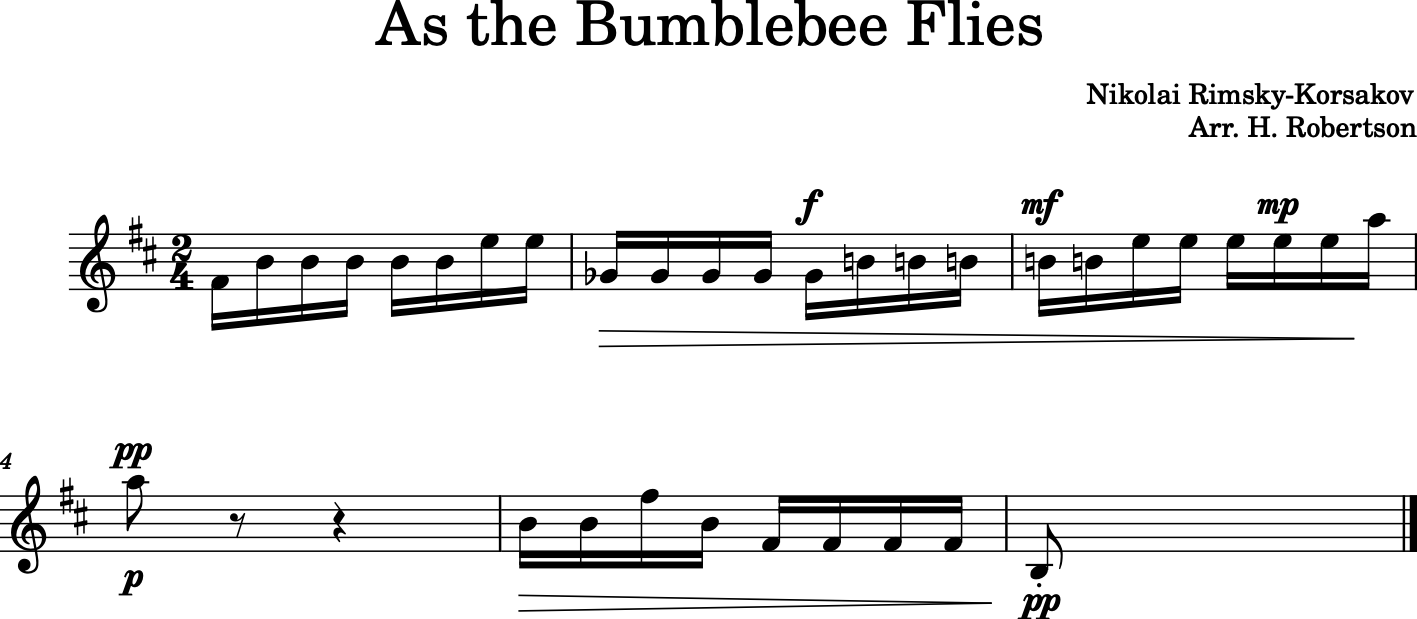

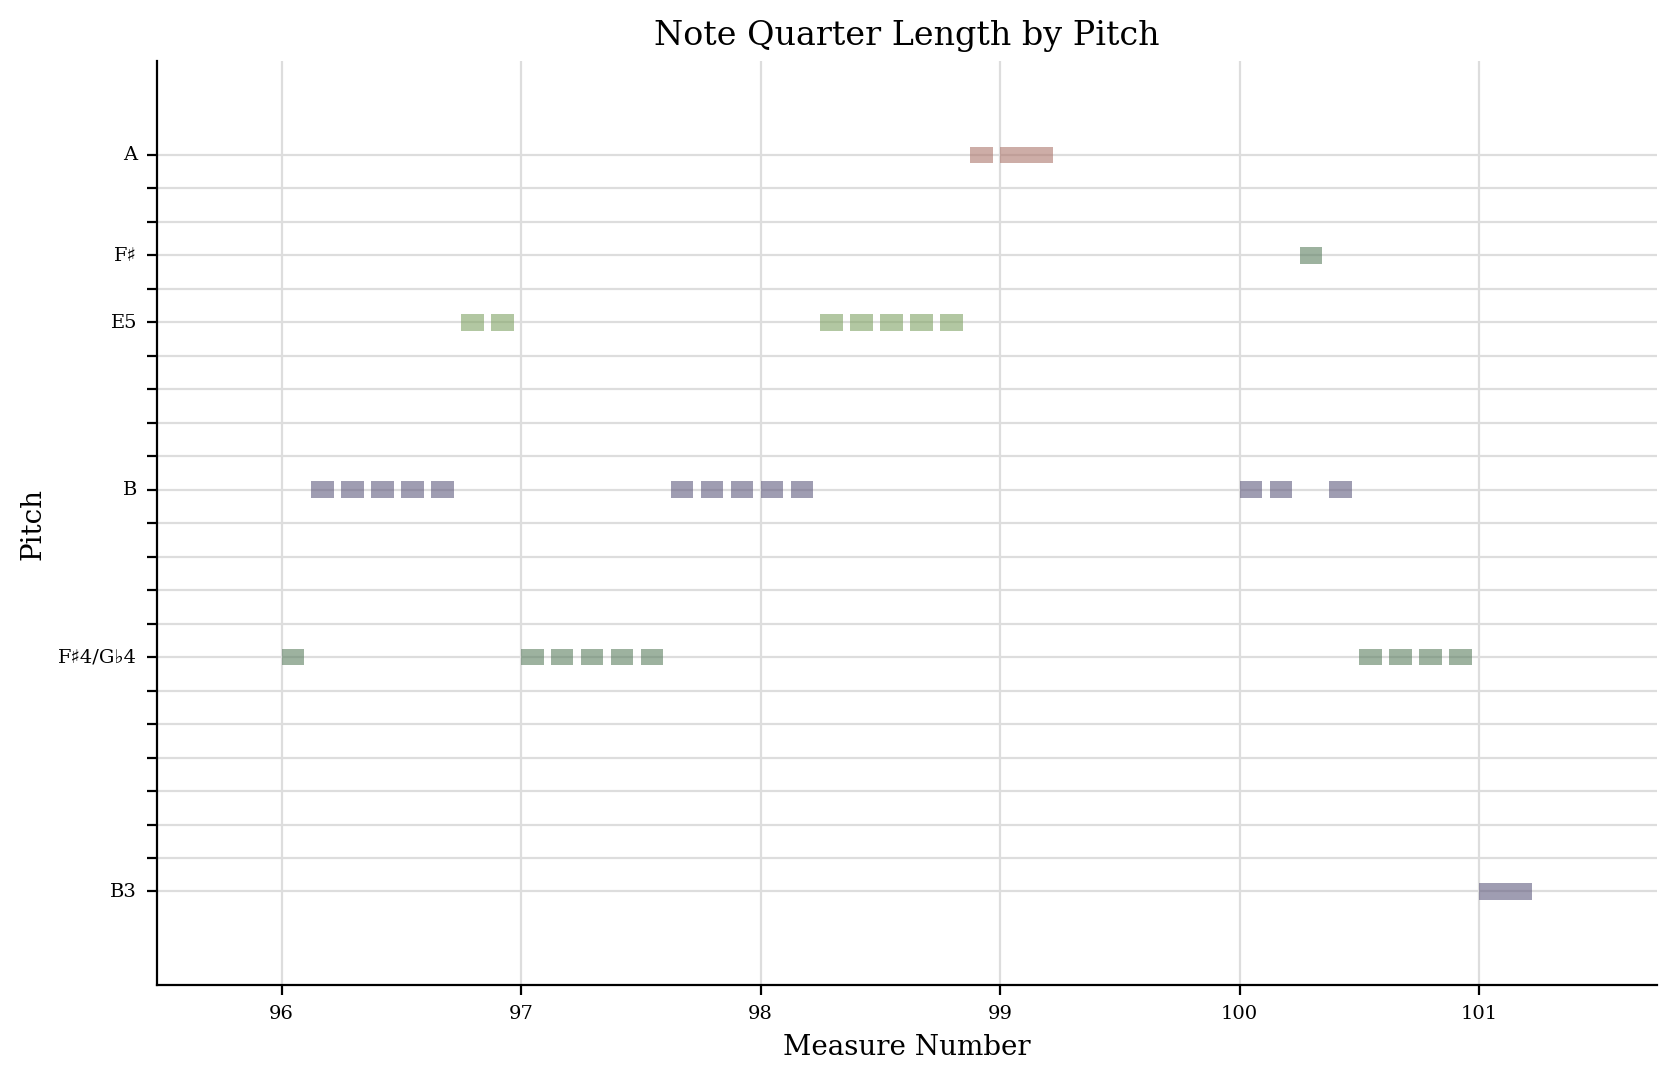

In [24]:
measure_count = len(score_crow.measureOffsetMap())
excerpt = score_crow.measures(measure_count-5, measure_count)
excerpt.show()
excerpt.show('midi')
excerpt.plot('pianoroll')